In [31]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import nibabel as nib
import pandas as pd
from glob import glob
import json


In [32]:
experiment_path = (
    "/Users/clairenastaskin/data/sub-Forest001/2026-04-09/fusi/task-ffalocalizer_run-002"
)

# Extract fUSI data and t_r
fusi_path = os.path.join(experiment_path, "sub-Forest001_ses-20260409_task-ffalocalizer_run-002_pwd.nii.gz")
fusi_data = nib.load(fusi_path)
fusi_data = fusi_data.get_fdata()

t_r_path = os.path.join(experiment_path, "t_r.npy")
t_r = np.load(t_r_path)

# Extract time_stamps
task_path = glob(os.path.join(experiment_path, '*events.tsv'))[0]
task_events = pd.read_csv(task_path, sep='\t')

# Extract json info
info_file_path = glob(os.path.join(experiment_path, "*pwd.json"))[0]
# Read the json file
with open(info_file_path, 'r') as f:
    info = json.load(f)

frame_times = info['VolumeTiming']
frame_times = np.array(frame_times)

In [33]:
coords = (57, 35, 43) # Coordinate of the pixel of interest (with high z-score for example from freeview) from the non-realigned data 
radius = 2
timecourse = np.mean(fusi_data[coords[0]-radius:coords[0]+radius,coords[1]-radius:coords[1]+radius,coords[2]-radius:coords[2]+radius,:],axis=(0,1,2))
np.save(
    os.path.join(experiment_path, f"time_course_coord_{coords[0]}-{coords[1]}-{coords[2]}_radius{radius}.npy"),
    timecourse
)
print(timecourse.shape)

(165,)


In [34]:
def boxcar_smooth(data, window_size):
    if window_size > 0:
        smoothed_data = np.copy(data)
        for t in range(data.shape[3]):
            start_index = max(0, t - window_size // 2)
            end_index = min(data.shape[3], t + window_size // 2 + 1)
            smoothed_data[:, :, :, t] = np.mean(
                data[:, :, :, start_index:end_index], axis=3
            )
    else:
        smoothed_data = data
    return smoothed_data


# Apply temporal smoothing with boxcar window
window_size = 3  # Number of time points to use for smoothing
timecourse = boxcar_smooth(timecourse[np.newaxis, np.newaxis, np.newaxis, :], window_size)[0,0,0,:]

In [35]:
# Detrend signal
from nilearn.signal import clean
# Reshape timecourse to 2D (nilearn expects shape: [n_timepoints, n_features])
timecourse_2d = timecourse[:, np.newaxis]  # Shape: (237, 1)
detrended_timecourse = clean(
    timecourse_2d[2:],  # Exclude the first two frames for detrending
    confounds=None,
    detrend=None,
    standardize=None,       
    low_pass=None,
    high_pass=0.01,
    t_r=t_r,
    ensure_finite=True,      # avoids NaN propagation
)
# Flatten back to 1D if needed
detrended_timecourse = detrended_timecourse.flatten()

# Exclude the first two frames (extreme values that throw off the signal)
detrended_timecourse = detrended_timecourse
frame_times = frame_times[2:]

In [36]:
power_doppler_time_course = pd.DataFrame(
    {
        "timestamp": frame_times,
        "power_doppler_value": detrended_timecourse,
    }
)

In [37]:
task_list_type = task_events.trial_type.unique()
print(task_list_type)


['scenes' 'faces' 'scrambled_faces']


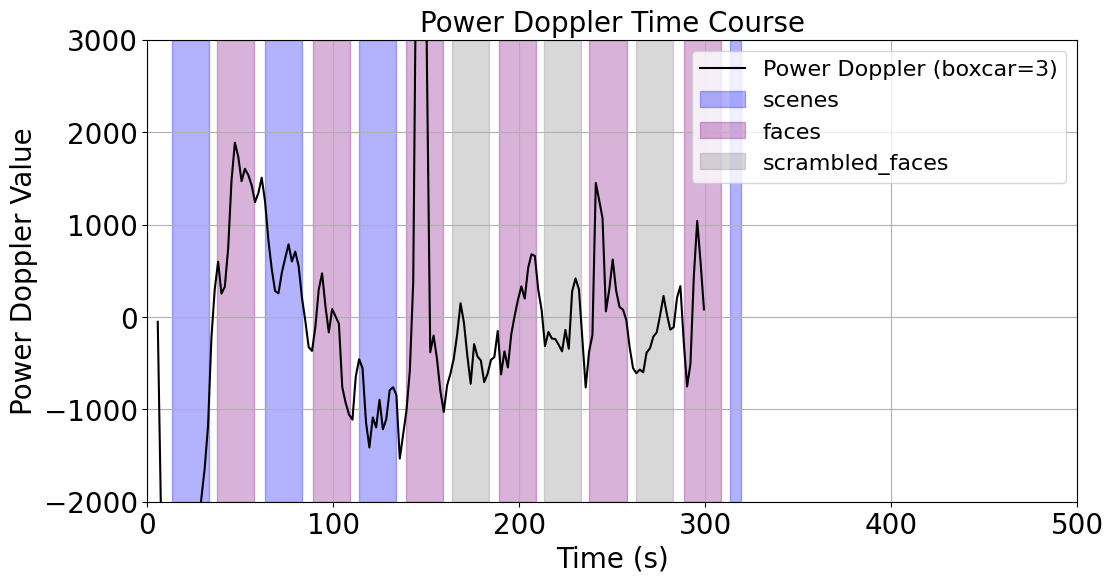

In [38]:
# Smooth the Power Doppler signal using a boxcar of width 2
signal = power_doppler_time_course.power_doppler_value; 

plt.figure(figsize=(12, 6))
plt.plot(
    power_doppler_time_course.timestamp,
    signal,
    color="black",
    label=f"Power Doppler (boxcar={window_size})"
)

task_colors = ['blue', 'purple', 'gray', 'lightgreen', 'red', 'orange', 'yellow', 'pink']

# Add colored rectangles for stimulus periods
for task_index in range(len(task_list_type)):
    task = task_list_type[task_index]
    task_events_timing = pd.DataFrame()
    task_events_timing["Event"] = ["start", "stop"] * len(
        task_events[task_events["trial_type"] == task]
    )
    task_events_timing["Timestamp"] = [
        onset
        for onset, duration in zip(
            task_events[task_events["trial_type"] == task]["onset"],
            task_events[task_events["trial_type"] == task]["duration"],
        )
        for _ in range(2)
    ]
    # No need to .values for pandas Series, just use .to_numpy() or direct array ops
    durations = task_events[task_events["trial_type"] == task]["duration"].to_numpy()
    task_events_timing.loc[task_events_timing["Event"] == "stop", "Timestamp"] += durations.repeat(1)
    task_events_timing = task_events_timing.sort_values("Timestamp").reset_index(drop=True)
    start_times = task_events_timing[task_events_timing["Event"] == "start"]["Timestamp"]
    stop_times = task_events_timing[task_events_timing["Event"] == "stop"]["Timestamp"]
    # Use .iloc for pandas Series, not numpy arrays
    for i, (start, stop) in enumerate(zip(start_times, stop_times)):
        plt.axvspan(start, stop, color=task_colors[task_index], alpha=0.3, label=task if i == 0 else "")

plt.xlabel("Time (s)", fontsize=20)
plt.ylabel("Power Doppler Value", fontsize=20)
plt.title("Power Doppler Time Course", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.ylim(-2000, 3000)
plt.xlim(0,500)
plt.grid(True)
plt.legend(fontsize=16)
plt.show()


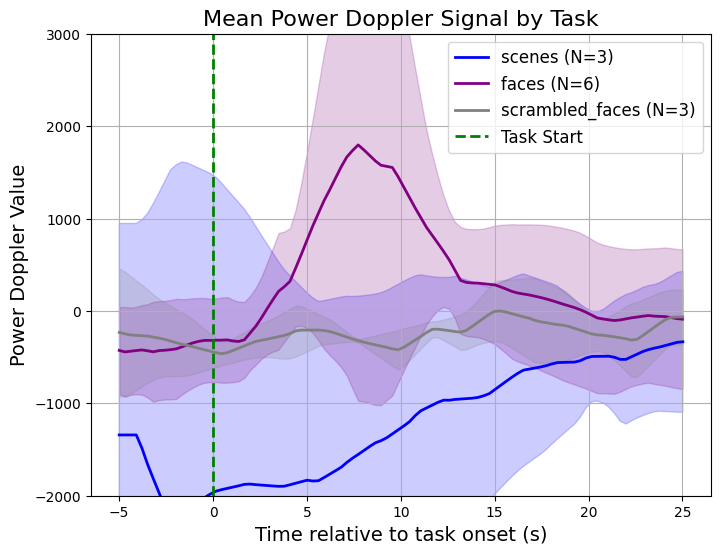

In [40]:

# Time window around events (in seconds)
window_before = 5
window_after = 5

plt.figure(figsize=(8, 6))

task_colors = ['blue', 'purple', 'gray', 'lightgreen', 'red', 'orange', 'yellow', 'pink']

for task_index, task in enumerate(task_list_type):
    task_events_filtered = task_events[task_events["trial_type"] == task]

    aligned_signals = []
    aligned_times = []

    for idx, (onset, duration) in enumerate(zip(task_events_filtered["onset"], task_events_filtered["duration"])):
        time_start = onset - window_before
        time_end = onset + duration + window_after

        mask = (power_doppler_time_course["timestamp"] >= time_start) & (power_doppler_time_course["timestamp"] <= time_end)
        subset = power_doppler_time_course[mask].copy()

        if len(subset) < 2:
            continue

        subset["relative_time"] = subset["timestamp"] - onset

        aligned_signals.append(subset["power_doppler_value"].values)
        aligned_times.append(subset["relative_time"].values)

    if len(aligned_signals) == 0:
        continue

    # Interpolate onto a common time grid
    common_time = np.linspace(-window_before, task_events_filtered.iloc[0]["duration"] + window_after, 100)
    interpolated = []
    for t, s in zip(aligned_times, aligned_signals):
        interpolated.append(np.interp(common_time, t, s))
    interpolated = np.stack(interpolated)

    mean_signal = interpolated.mean(axis=0)
    std_signal = interpolated.std(axis=0)

    color = task_colors[task_index % len(task_colors)]

    plt.plot(common_time, mean_signal, color=color, linewidth=2,
             label=f'{task} (N={len(aligned_signals)})')
    plt.fill_between(common_time, mean_signal - std_signal, mean_signal + std_signal,
                     color=color, alpha=0.2)

# Add vertical line to mark task start
plt.axvline(x=0, color='green', linestyle='--', linewidth=2, label='Task Start')

plt.xlabel("Time relative to task onset (s)", fontsize=14)
plt.ylabel("Power Doppler Value", fontsize=14)
plt.ylim(-2000, 3000)
plt.title("Mean Power Doppler Signal by Task", fontsize=16)
plt.grid(True)
plt.legend(fontsize=12)
plt.show()
